In [1]:
# ch04_TOOL_AND_MEMORY.ipynb

In [27]:
from dotenv import load_dotenv
load_dotenv()

True

In [28]:
!pip install -U langchain-tavily
from langchain_tavily import TavilySearch


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [29]:
tool = TavilySearch(max_results=2)
tools = [tool]

In [30]:
tool.invoke("랭그래프에서 '노드'란 무엇인가요?")

{'query': "랭그래프에서 '노드'란 무엇인가요?",
 'response_time': 0.91,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://m.blog.naver.com/pjt3591oo/223861729229',
   'title': 'langgraph 소개 및 기본개념 : 네이버 블로그',
   'content': '· 노드(nodes): 그래프의 작업 단위\u200b 노드는 그래프에서 실제 작업을 수행하는 단위입니다. 각 노드는 특정 로직을 담당합니다. 작업은 LLM 호출, 데이터',
   'score': 0.8332299,
   'raw_content': None},
  {'url': 'https://normalstory.tistory.com/entry/LangGraph-01',
   'title': 'LangGraph - 1. 개요 - 청춘만화 - 티스토리',
   'content': "***\\*지극히 주관적 개요:*** *Devika, Crew AI, phidata를 사용하면서 또는 사용할수록 강하게 느껴지는 점이 하나 있다면 지금 중요한 것은 ’ 프롬프트나 RAG가 아니라 얼마나 Agentic 한 LLM 애플리케이션을 얼마나 Locally 하게 구성할 수 있는가 ‘라고 생각한다.* *물론 이때 구성의 주체는 operater가 아니라 End-User이다. LangGraph는 Agent 런타임에 자주 필요한 '**주기적 그래프***workflows containing**cycles*'를 더 잘 생성할 수 있도록 LangChain 위에 구축된 모듈이다. 그리고 프로세스의 '방향'은 프로세스 내 워크의 상태(실행 여부나 그 상태) 정보를 기반으로 이뤄지는데 이러한 일련의 내용은 기본적으로 scratch 코딩과 같이\xa0그래프( workflows,\xa0diagram)형태로 표현될 수 있다. 2. 속성의 값을 추가하는 말 그대로

In [31]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("openai:gpt-4.1")
llm_with_tools = llm.bind_tools(tools)

In [32]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [33]:
graph_builder.add_node("chatbot", chatbot)

In [34]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """챗봇이 요청한 도구를 실행하는 노드입니다."""

    def __init__(self, tools: list):
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        messages = inputs.get("messages", [])
        if not messages:
            raise ValueError("입력된 상태에서 메시지를 찾을 수 없습니다.")

        outputs = []
        for tool_call in messages[-1].tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(tool_call["args"])
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"]
                )
            )
        return {"messages": outputs}

tool_node = BasicToolNode(tools=[tool])

In [35]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools=[tool])

In [36]:
graph_builder.add_node("tools", tool_node)

In [37]:
def route_tools(state: State):
    """
    마지막 챗봇 메시지에서 도구 호출(tool_calls)이 있는지 확인하여
    있으면 'tools' 노드로, 없으면 종료(END)로 이동합니다.
    """
    ai_message = state["messages"][-1]

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"  # 도구 호출이 있으면 도구 노드로 이동
    return END  # 도구 호출이 없으면 종료

graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    {"tools": "tools", END: END}
)

In [38]:
from langgraph.prebuilt import tools_condition

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

In [39]:
# 도구 호출 후 챗봇으로 돌아가는 경로 설정
graph_builder.add_edge("tools", "chatbot")

# 그래프의 시작점 설정
graph_builder.add_edge(START, "chatbot")

# 그래프 완성 및 컴파일
graph = graph_builder.compile()

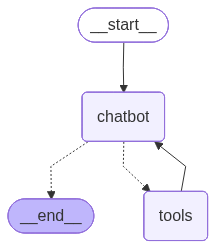

In [40]:
from IPython.display import Image, display

try:
    # Mermaid 기반으로 생성된 PNG 그래프를 출력
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # 시각화에 필요한 의존성 패키지가 없다면 예외 처리
    pass

In [41]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

In [42]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break

    stream_graph_updates(user_input)

Assistant: 랭그래프에서 “엣지(Edge)”란 그래프의 요소 중 하나로, **그래프 상의 두 노드(점, vertex)를 연결하는 선분** 또는 **연결선**을 의미합니다.

### 설명
- **노드(Node, Vertex):** 그래프의 한 점, 데이터 단위.
- **엣지(Edge):** 두 노드를 연결하는 관계.  
  예를 들어, “A — B”에서 ‘—’ 부분이 엣지입니다.

### 랭그래프(LangGraph)와 엣지
랭그래프에서 엣지는 보통 **언어 모델 기반 워크플로우에서 단계 간 데이터 또는 제어 흐름의 연결**을 의미합니다. 즉, 어떤 프로세스나 상태에서 다음 단계로 “이동할 수 있게 해주는 연결”이 엣지입니다.

#### 예시
- **챗봇 설계**에서 “질문 받기(노드 A)”에서 “답변 생성(노드 B)”로 이동하는 경로가 있을 경우,
  - 이 경로(선)가 **엣지**입니다.
- **유형**
  - **방향성(Directional) 엣지:** ‘A → B’처럼 이동 방향이 정해진 경우.
  - **비방향성(Undirectional) 엣지:** ‘A — B’처럼 양방향 연결만 있고 특별한 방향이 없는 경우.

### 요약
- **엣지란?**: 그래프에서 두 노드(점)을 연결하는 선, 흐름 또는 관계.
- **랭그래프에서의 의미:** 워크플로우, 상태, 로직 등 다양한 단계들을 연결하는 경로 및 트리거 역할.

궁금한 점 있으면 언제든 질문해 주세요!
Assistant: 
Assistant: {"query": "랭그래프 엣지", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=W_uwR_yx4-c", "title": "#LangGraph 개념 완전 정복 몰아보기(3시간) - YouTube", "content": "가지고 갔어요. 그래서 피드백을 받고 수정을 하고 다시 가고 피드백 받고 다시 가고

In [43]:
# MEMORY

In [44]:
from dotenv import load_dotenv
load_dotenv()

True

In [45]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [46]:
graph = graph_builder.compile(checkpointer=memory)

In [47]:
config = {"configurable": {"thread_id": "1"}}
user_input = "안녕하세요! 제 이름은 랭체인입니다."

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

안녕하세요! 제 이름은 랭체인입니다.
================================== Ai Message ==================================

안녕하세요, 랭체인님! 만나서 반갑습니다. 어떤 도움이 필요하신가요? 궁금한 점이 있으면 언제든 말씀해 주세요! 😊


In [48]:
user_input = "내 이름이 뭐였나요?"

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

내 이름이 뭐였나요?
================================== Ai Message ==================================

당신의 이름은 “랭체인”이라고 하셨습니다!😊  
다른 궁금한 점이나 필요한 것이 있으면 언제든 말씀해 주세요.


In [49]:
snapshot = graph.get_state(config)
print(snapshot)

StateSnapshot(values={'messages': [HumanMessage(content='안녕하세요! 제 이름은 랭체인입니다.', additional_kwargs={}, response_metadata={}, id='d34c954c-ae3b-40de-aa05-98210571f814'), AIMessage(content='안녕하세요, 랭체인님! 만나서 반갑습니다. 어떤 도움이 필요하신가요? 궁금한 점이 있으면 언제든 말씀해 주세요! 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 1199, 'total_tokens': 1237, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_1a2c4a5ede', 'id': 'chatcmpl-CzKl2w2fRtgikAHGLxUTDSOJoNWvB', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019bd0c0-8248-7e90-9d91-2a0e7fa2abbf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1199, 'output_tokens': 38, 'total_tokens': 1237, 'inp

In [50]:
snapshot.next  # 다음 실행될 노드 (대화가 끝났다면 빈 튜플)

()

In [51]:
snapshot.values  # 현재까지의 메시지 리스트

{'messages': [HumanMessage(content='안녕하세요! 제 이름은 랭체인입니다.', additional_kwargs={}, response_metadata={}, id='d34c954c-ae3b-40de-aa05-98210571f814'),
  AIMessage(content='안녕하세요, 랭체인님! 만나서 반갑습니다. 어떤 도움이 필요하신가요? 궁금한 점이 있으면 언제든 말씀해 주세요! 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 1199, 'total_tokens': 1237, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_1a2c4a5ede', 'id': 'chatcmpl-CzKl2w2fRtgikAHGLxUTDSOJoNWvB', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019bd0c0-8248-7e90-9d91-2a0e7fa2abbf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1199, 'output_tokens': 38, 'total_tokens': 1237, 'input_token_details': 